In [1]:
import gym
import energym

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import time

In [2]:
from stable_baselines3 import DQN

In [48]:
# Parameters:
years = 7

frequency = 4   # DA on every hour

gamma = 0.9
learning_starts = 35040/2   # training starts 6 months in
target_update_interval = 5000
buffer_size = 1000000
exploration_fraction = 0.8
exploration_initial_eps = 1
exploration_final_eps = 0.05
total_timesteps = years * 35040   # 7 years for training
eval_freq = 35040/2

In [3]:
pip install shimmy>=0.2.1

Note: you may need to restart the kernel to use updated packages.


In [50]:
########  Regular DQN run with no DA (hot environment)  ########


# Create environment:
env = gym.make('Eplus-discrete-hot-v1')

# Create model:
model = DQN("MlpPolicy", env, verbose=1, 
        gamma = gamma,
        learning_starts = learning_starts,
        target_update_interval = target_update_interval,
        buffer_size = buffer_size,
        exploration_fraction = exploration_fraction,
        exploration_initial_eps = exploration_initial_eps,
        exploration_final_eps = exploration_final_eps)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [51]:
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.evaluation import evaluate_policy

# Create environment:
env = gym.make('Eplus-discrete-hot-v1')

# Create a separate environment for evaluation
eval_env = gym.make('Eplus-discrete-hot-v1')

# Create model:
model = DQN("MlpPolicy", env, verbose=1, 
        gamma = gamma,
        learning_starts = learning_starts,
        target_update_interval = target_update_interval,
        buffer_size = buffer_size,
        exploration_fraction = exploration_fraction,
        exploration_initial_eps = exploration_initial_eps,
        exploration_final_eps = exploration_final_eps)

# Create the evaluation callback
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./logs/",
    log_path="./logs/",
    eval_freq=int(eval_freq),
    n_eval_episodes=1,
    deterministic=True,
    render=False
)

# Train model:
start_time = time.time()

model.learn(total_timesteps = total_timesteps, callback=eval_callback)

print()
print("--- %s seconds taken to train ---" % (time.time() - start_time))

#model.save("DQN models/regular_DQN_hot")

env.close()
eval_env.close()

[2025-05-08 12:16:45,200] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-08 12:16:45,200] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-08 12:16:45,200] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-08 12:16:45,200] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-08 12:16:45,200] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-08 12:16:45,200] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-08 12:16:45,200] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-08 12:16:45,200] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-08 12:16:45,200] EPLUS_ENV_discrete-hot

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


[2025-05-08 12:16:45,224] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:EnergyPlus working directory is in /code/Eplus-env-discrete-hot-v1-res20/Eplus-env-sub_run1
[2025-05-08 12:16:45,224] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:EnergyPlus working directory is in /code/Eplus-env-discrete-hot-v1-res20/Eplus-env-sub_run1
[2025-05-08 12:16:45,224] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:EnergyPlus working directory is in /code/Eplus-env-discrete-hot-v1-res20/Eplus-env-sub_run1
[2025-05-08 12:16:45,224] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:EnergyPlus working directory is in /code/Eplus-env-discrete-hot-v1-res20/Eplus-env-sub_run1
[2025-05-08 12:16:45,224] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:EnergyPlus working directory is in /code/Eplus-env-discrete-hot-v1-res20/Eplus-env-sub_run1
[2025-05-08 12:16:45,224] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:EnergyPlus working directory is in /code/Eplus-env-discrete-hot-v1-res20/Eplus-env-sub_run1
[2025-05-0

KeyboardInterrupt: 

In [ ]:
# Train model:

start_time = time.time()

model.learn(total_timesteps = total_timesteps, 
        eval_freq = eval_freq, 
        n_eval_episodes = 1)

print()
print("--- %s seconds taken to train ---" % (time.time() - start_time))


#model.save("DQN models/regular_DQN_hot")

env.close()

In [ ]:
!pip install tqdm

In [ ]:
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
from tqdm.notebook import tqdm

class ProgressBarCallback(BaseCallback):
    """
    Display a progress bar when training SB3 agent
    """
    def __init__(self, total_timesteps):
        super().__init__()
        self.pbar = None
        self.total_timesteps = total_timesteps
        
    def _on_training_start(self):
        self.pbar = tqdm(total=self.total_timesteps)

    def _on_step(self):
        self.pbar.update(1)
        return True
    
    def _on_training_end(self):
        self.pbar.close()
        self.pbar = None

# Create environment:
env = gym.make('Eplus-discrete-hot-v1')

# Create a separate environment for evaluation
eval_env = gym.make('Eplus-discrete-hot-v1')

# Create model:
model = DQN("MlpPolicy", env, verbose=1, 
        gamma = gamma,
        learning_starts = learning_starts,
        target_update_interval = target_update_interval,
        buffer_size = buffer_size,
        exploration_fraction = exploration_fraction,
        exploration_initial_eps = exploration_initial_eps,
        exploration_final_eps = exploration_final_eps)

# Create the evaluation callback
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./logs/",
    log_path="./logs/",
    eval_freq=int(eval_freq),
    n_eval_episodes=1,
    deterministic=True,
    render=False
)

# Create the progress bar callback
progress_callback = ProgressBarCallback(total_timesteps=total_timesteps)

# Combine callbacks
from stable_baselines3.common.callbacks import CallbackList
callbacks = CallbackList([progress_callback, eval_callback])

# Train model:
start_time = time.time()

model.learn(total_timesteps=total_timesteps, callback=callbacks)

print()
print("--- %s seconds taken to train ---" % (time.time() - start_time))

#model.save("DQN models/regular_DQN_hot")

env.close()
eval_env.close()

In [ ]:
python --version

In [ ]:
# Test model for 1 year:

model = DQN.load("DQN models/regular_DQN_hot")

env = gym.make('Eplus-discrete-hot-v1')


start_time = time.time()

for i in range(1):
    obs = env.reset()

    rewards = []
    total_power = []
    in_temp = []
    out_temp = []
    actions = []
    comfort_penalties = []
    done = False
    current_month = 0

    while not done:
        # Predict next step:
        a, _ = model.predict(obs)
        # Observe next state and reward:
        obs, reward, done, info = env.step(int(a))

        # Store information for plotting:
        rewards.append(reward)
        total_power.append(info['total_power'])
        in_temp.append(info['temperature'])
        out_temp.append(info['out_temperature'])
        actions.append(int(a))
        comfort_penalties.append(info['comfort_penalty'])

        if info['month'] != current_month: # display results every month
            current_month = info['month']
            print('Reward: ', sum(rewards), info)
    print('Episode ', i, 'Mean reward: ', np.mean(rewards), 'Cumulative reward: ', sum(rewards))
env.close()



print()
print("--- %s seconds taken to run ---" % (time.time() - start_time))

In [ ]:
fig, axes = plt.subplots(nrows = 3, ncols = 2, figsize = (12,12))

axes[0,0].plot(in_temp)
axes[0,0].set_title('Indoor temperature ($^\circ$C)')
axes[0,0].set_xlabel('timestep')
axes[0,0].set_ylabel('temperature')

axes[0,1].plot(out_temp)
axes[0,1].set_title('Outdoor temperature ($^\circ$C)')
axes[0,1].set_xlabel('timestep')
axes[0,1].set_ylabel('temperature')

axes[1,0].plot(total_power)
axes[1,0].set_title('Power usage')
axes[1,0].set_xlabel('timestep')
axes[1,0].set_ylabel('units')

axes[1,1].plot(rewards)
axes[1,1].set_title('Reward')
axes[1,1].set_xlabel('timestep')
axes[1,1].set_ylabel('units')

axes[2,0].hist(actions, rwidth = 0.5)
axes[2,0].set_title('Actions taken')
axes[2,0].set_xlabel('action')
axes[2,0].set_ylabel('frequency')

axes[2,1].plot(comfort_penalties)
axes[2,1].set_title('Comfort penalty each timestep')
axes[2,1].set_xlabel('timestep')
axes[2,1].set_ylabel('comfort penalty ($^\circ$C)')


plt.tight_layout()


plt.savefig('project_images/DQN_metrics_hot.png')

In [ ]:
winter = actions[33700:] + actions[:7450]
spring = actions[7450:16150]
summer = actions[16150:24900]
autumn = actions[24900:33700]

len(winter), len(spring), len(summer), len(autumn)

In [ ]:
# split actions into seasons

fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (12,8))

axes[0,0].hist(winter, rwidth = 0.5)
axes[0,0].set_title('Winter')
axes[0,0].set_xlabel('action')
axes[0,0].set_ylabel('frequency')

axes[0,1].hist(spring, rwidth = 0.5)
axes[0,1].set_title('Spring')
axes[0,1].set_xlabel('action')
axes[0,1].set_ylabel('frequency')

axes[1,0].hist(summer, rwidth = 0.5)
axes[1,0].set_title('Summer')
axes[1,0].set_xlabel('action')
axes[1,0].set_ylabel('frequency')

axes[1,1].hist(autumn, rwidth = 0.5)
axes[1,1].set_title('Autumn')
axes[1,1].set_xlabel('action')
axes[1,1].set_ylabel('frequency')


plt.tight_layout()

In [ ]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (10,5))

ax.hist([winter, spring, summer, autumn], rwidth = 0.8, 
            label = ['winter', 'spring', 'summer', 'autumn'], bins = np.arange(11) - 0.5)

ax.set_title('Actions by season')
ax.set_xlabel('action')
ax.set_ylabel('frequency')

ax.legend()

ax.set_ylim([0,5300])

#ax.set(xticks=range(10), xlim=[-1, 10])

ax.set_xticks(list(range(10)))


plt.savefig('project_images/DQN_actions_by_season_hot.png')

In [ ]:
print("Total comfort penalty:", sum(comfort_penalties))
print()
print("Number of comfort penalties:", sum([0 if (x == 0) else 1 for x in comfort_penalties]))

In [ ]:
# See how the actions vary during the day (7am-7pm) / night (7pm-7am):



day_time_steps = [(i*96 + j) for i in range(0, 365) for j in range(28,76)]

night_time_steps = [(i*96 + j) for i in range(0, 364) for j in range(76,124)]



day_actions = [actions[day_time_steps[i]] for i in range(len(day_time_steps))]

night_actions = [actions[night_time_steps[i]] for i in range(len(night_time_steps))]


In [ ]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (10,5))

ax.hist([day_actions, night_actions], rwidth = 0.8, 
            label = ['daytime', 'nighttime'], bins = np.arange(11) - 0.5)

ax.set_title('Actions by time of day')
ax.set_xlabel('action')
ax.set_ylabel('frequency')

ax.legend()

ax.set_xticks(list(range(10)))


plt.savefig('project_images/DQN_actions_by_time_hot.png')

In [ ]:
########  DQN run with DA (hot environment) ########

In [ ]:
from stable_baselines3.common.callbacks import BaseCallback

class DataAssimilationCallback(BaseCallback):
    
    def __init__(self, check_freq, actual_temp = None, actual_power = None, 
                  temp_DA = False, power_DA = False, both_DA = False, verbose=1):
        super(DataAssimilationCallback, self).__init__(verbose)
        self.check_freq = check_freq
        # Number of time the callback was called:
        self.n_calls = 0
        # Actual states after step:
        self.actual_temp = actual_temp
        self.actual_power = actual_power

        self.count = 0

        self.temp_DA = temp_DA
        self.power_DA = power_DA
        self.both_DA = both_DA



    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq == 0:

          if self.temp_DA:
            env.update_temp(self.actual_temp[self.count])

          elif self.power_DA:
            env.update_power(self.actual_power[self.count])

          elif self.both_DA:
            env.update_both(self.actual_temp[self.count], self.actual_power[self.count])

          self.count += 4
          

        return True    # set false for just one step

In [ ]:
df = pd.read_csv("mean_runs/hot_means.csv")

df.head()

In [ ]:
new_temps = df['indoor_temp_mean'].tolist()

new_power = df['total_power_mean'].tolist()

new_temps[:5], new_power[:5]

In [ ]:
# ###### Temp DA only ######


# # Create environment:
# env = gym.make('Eplus-discrete-hot-v1')

# # Create model:
# model = DQN("MlpPolicy", env, verbose=1, 
#         gamma = gamma,
#         learning_starts = learning_starts,
#         target_update_interval = target_update_interval,
#         buffer_size = buffer_size,
#         exploration_fraction = exploration_fraction,
#         exploration_initial_eps = exploration_initial_eps,
#         exploration_final_eps = exploration_final_eps)


# # Callback:
# callback = DataAssimilationCallback(check_freq = frequency, actual_temp = years*new_temps, temp_DA = True)

In [ ]:
# start_time = time.time()

# model.learn(total_timesteps=total_timesteps, 
#             eval_freq = eval_freq, 
#             n_eval_episodes = 1, 
#             callback=callback)

# print()
# print("--- %s seconds taken to train ---" % (time.time() - start_time))


# #model.save("DQN models/temp_DA_DQN_hot")

# env.close()

In [ ]:
# ###### Temp DA only ######

# # Create environment:
# env = gym.make('Eplus-discrete-hot-v1')
# eval_env = gym.make('Eplus-discrete-hot-v1')

# # Create model:
# model = DQN("MlpPolicy", env, verbose=1, 
#         gamma = gamma,
#         learning_starts = learning_starts,
#         target_update_interval = target_update_interval,
#         buffer_size = buffer_size,
#         exploration_fraction = exploration_fraction,
#         exploration_initial_eps = exploration_initial_eps,
#         exploration_final_eps = exploration_final_eps)

# # Create the evaluation callback
# eval_callback = EvalCallback(
#     eval_env,
#     best_model_save_path="./logs/",
#     log_path="./logs/",
#     eval_freq=int(eval_freq),
#     n_eval_episodes=1,
#     deterministic=True,
#     render=False
# )

# # Data Assimilation Callback:
# da_callback = DataAssimilationCallback(check_freq=frequency, actual_temp=years*new_temps, temp_DA=True)

# # Combine callbacks
# from stable_baselines3.common.callbacks import CallbackList
# callbacks = CallbackList([da_callback, eval_callback])

# start_time = time.time()

# model.learn(total_timesteps=total_timesteps, callback=callbacks)

# print()
# print("--- %s seconds taken to train ---" % (time.time() - start_time))

# #model.save("DQN models/temp_DA_DQN_hot")

# env.close()
# eval_env.close()

In [ ]:
# Install tqdm if not already installed
#!pip install tqdm

from stable_baselines3.common.callbacks import BaseCallback, EvalCallback, CallbackList
from tqdm.notebook import tqdm

class ProgressBarCallback(BaseCallback):
    """
    Display a progress bar when training SB3 agent
    """
    def __init__(self, total_timesteps):
        super().__init__()
        self.pbar = None
        self.total_timesteps = total_timesteps
        
    def _on_training_start(self):
        self.pbar = tqdm(total=self.total_timesteps)

    def _on_step(self):
        self.pbar.update(1)
        return True
    
    def _on_training_end(self):
        self.pbar.close()
        self.pbar = None

###### Temp DA only ######

# Create environment:
env = gym.make('Eplus-discrete-hot-v1')
eval_env = gym.make('Eplus-discrete-hot-v1')

# Create model:
model = DQN("MlpPolicy", env, verbose=1, 
        gamma = gamma,
        learning_starts = learning_starts,
        target_update_interval = target_update_interval,
        buffer_size = buffer_size,
        exploration_fraction = exploration_fraction,
        exploration_initial_eps = exploration_initial_eps,
        exploration_final_eps = exploration_final_eps)

# Create the evaluation callback
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./logs/",
    log_path="./logs/",
    eval_freq=int(eval_freq),
    n_eval_episodes=1,
    deterministic=True,
    render=False
)

# Data Assimilation Callback:
da_callback = DataAssimilationCallback(check_freq=frequency, actual_temp=years*new_temps, temp_DA=True)

# Progress bar callback
progress_callback = ProgressBarCallback(total_timesteps=total_timesteps)

# Combine callbacks
callbacks = CallbackList([da_callback, eval_callback, progress_callback])

start_time = time.time()

model.learn(total_timesteps=total_timesteps, callback=callbacks)

print()
print("--- %s seconds taken to train ---" % (time.time() - start_time))

#model.save("DQN models/temp_DA_DQN_hot")

env.close()
eval_env.close()

In [ ]:
# Test model for 1 year:

model = DQN.load("DQN models/temp_DA_DQN_hot")  

env = gym.make('Eplus-discrete-hot-v1')


start_time = time.time()

for i in range(1):
    obs = env.reset()

    rewards = []
    total_power = []
    in_temp = []
    out_temp = []
    actions = []
    comfort_penalties = []
    done = False
    current_month = 0

    while not done:
        # Predict next step:
        a, _ = model.predict(obs)
        # Observe next state and reward:
        obs, reward, done, info = env.step(int(a))

        # Store information for plotting:
        rewards.append(reward)
        total_power.append(info['total_power'])
        in_temp.append(info['temperature'])
        out_temp.append(info['out_temperature'])
        actions.append(int(a))
        comfort_penalties.append(info['comfort_penalty'])

        if info['month'] != current_month: # display results every month
            current_month = info['month']
            print('Reward: ', sum(rewards), info)
    print('Episode ', i, 'Mean reward: ', np.mean(rewards), 'Cumulative reward: ', sum(rewards))
env.close()


print()
print("--- %s seconds taken to run ---" % (time.time() - start_time))

In [ ]:
fig, axes = plt.subplots(nrows = 3, ncols = 2, figsize = (12,12))

axes[0,0].plot(in_temp)
axes[0,0].set_title('Indoor temperature ($^\circ$C)')
axes[0,0].set_xlabel('timestep')
axes[0,0].set_ylabel('temperature')

axes[0,1].plot(out_temp)
axes[0,1].set_title('Outdoor temperature ($^\circ$C)')
axes[0,1].set_xlabel('timestep')
axes[0,1].set_ylabel('temperature')

axes[1,0].plot(total_power)
axes[1,0].set_title('Power usage')
axes[1,0].set_xlabel('timestep')
axes[1,0].set_ylabel('units')

axes[1,1].plot(rewards)
axes[1,1].set_title('Reward')
axes[1,1].set_xlabel('timestep')
axes[1,1].set_ylabel('units')

axes[2,0].hist(actions, rwidth = 0.5)
axes[2,0].set_title('Actions taken')
axes[2,0].set_xlabel('action')
axes[2,0].set_ylabel('frequency')

axes[2,1].plot(comfort_penalties)
axes[2,1].set_title('Comfort penalty each timestep')
axes[2,1].set_xlabel('timestep')
axes[2,1].set_ylabel('comfort penalty ($^\circ$C)')


plt.tight_layout()


plt.savefig('project_images/DA_DQN_metrics_hot.png')

In [ ]:
winter = actions[33700:] + actions[:7450]
spring = actions[7450:16150]
summer = actions[16150:24900]
autumn = actions[24900:33700]

len(winter), len(spring), len(summer), len(autumn)

In [ ]:
# split actions into seasons

fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (12,8))

axes[0,0].hist(actions[34000:] + actions[:7450], rwidth = 0.5)
axes[0,0].set_title('Winter')
axes[0,0].set_xlabel('action')
axes[0,0].set_ylabel('frequency')

axes[0,1].hist(actions[7450:16150], rwidth = 0.5)
axes[0,1].set_title('Spring')
axes[0,1].set_xlabel('action')
axes[0,1].set_ylabel('frequency')

axes[1,0].hist(actions[16150:24900], rwidth = 0.5)
axes[1,0].set_title('Summer')
axes[1,0].set_xlabel('action')
axes[1,0].set_ylabel('frequency')

axes[1,1].hist(actions[24900:34000], rwidth = 0.5)
axes[1,1].set_title('Autumn')
axes[1,1].set_xlabel('action')
axes[1,1].set_ylabel('frequency')


plt.tight_layout()

In [ ]:
fig, ax = plt.subplots(nrows =1, ncols = 1, figsize = (10,5))

ax.hist([winter, spring, summer, autumn], rwidth = 0.8, 
            label = ['winter', 'spring', 'summer', 'autumn'], bins = np.arange(11) - 0.5)

ax.set_title('Actions by season')
ax.set_xlabel('action')
ax.set_ylabel('frequency')

ax.legend()

ax.set_ylim([0,5000])

ax.set_xticks(list(range(10)))


plt.savefig('project_images/DA_DQN_actions_by_season_hot.png')

In [ ]:
print("Total comfort penalty:", sum(comfort_penalties))
print()
print("Number of comfort penalties:", sum([0 if (x == 0) else 1 for x in comfort_penalties]))

# ALL DQN

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 1.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.8/362.8 kB 3.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 3.9 MB/s eta 0:00:00


/usr/local/lib/python3.7/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:50: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  "You provided an OpenAI Gym environment. "
/usr/local/lib/python3.7/dist-packages/gym/utils/passive_env_checker.py:175: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  "Future gym versions will require that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator."
/usr/local/lib/python3.7/dist-packages/gym/utils/passive_env_checker.py:188: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed `options` to allow the environment initialisation to

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Testing environment update functions before training...

=== Testing Environment Update Functions ===


/usr/local/lib/python3.7/dist-packages/gym/utils/passive_env_checker.py:196: UserWarning: WARN: The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional information. Actual type: `<class 'numpy.ndarray'>`
  f"The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional information. Actual type: `{type(result)}`"
/usr/local/lib/python3.7/dist-packages/gym/utils/passive_env_checker.py:220: DeprecationWarning: WARN: Core environment is written in old step API which returns one bool instead of two. It is recommended to rewrite the environment with new step API. 
  "Core environment is written in old step API which returns one bool instead of two. "
/usr/local/lib/python3.7/dist-packages/gym/utils/passive_env_checker.py:142: UserWarning: WARN: The obs returned by the `step()` method was expecting

Observation shape: (19,)
Current observation available with shape: (19,)
Calling update_temp with new temperature: 25.90
Temperature update test:
  Initial: 20.90°C
  Target: 25.90°C
  After update: 20.90°C
  Change applied: 0.00°C
  After step: 19.25°C


...

[2025-05-09 14:19:28,819] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Last EnergyPlus process has been closed. 
[2025-05-09 14:19:28,819] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Last EnergyPlus process has been closed. 
[2025-05-09 14:19:28,819] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Last EnergyPlus process has been closed. 
[2025-05-09 14:19:28,819] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Last EnergyPlus process has been closed. 
[2025-05-09 14:19:28,819] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Last EnergyPlus process has been closed. 
[2025-05-09 14:19:28,819] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Last EnergyPlus process has been closed. 
[2025-05-09 14:19:28,826] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-09 14:19:28,826] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-09 14:19:28,826] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO

Eval num_timesteps=245280, episode_reward=-22017.02 +/- 0.00
Episode length: 35040.00 +/- 0.00
----------------------------------
| eval/               |          |
|    mean_ep_length   | 3.5e+04  |
|    mean_reward      | -2.2e+04 |
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    total_timesteps  | 245280   |
| train/              |          |
|    learning_rate    | 0.0003   |
|    loss             | 5.55     |
|    n_updates        | 56939    |
----------------------------------
Reached end of DA data, resetting to beginning
DA Summary: 122640 updates performed out of 245280 total steps
Sample of before/after temperature values:
  Sample 1: Before=20.04, After=20.04, Diff=0.00
  Sample 2: Before=19.15, After=19.15, Diff=-0.00
  Sample 3: Before=19.59, After=19.59, Diff=-0.00
  Sample 4: Before=19.31, After=19.31, Diff=0.00
  Sample 5: Before=17.88, After=17.88, Diff=0.00
  Sample 6: Before=19.37, After=19.37, Diff=-0.00


[2025-05-09 14:20:40,586] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-09 14:20:40,586] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-09 14:20:40,586] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-09 14:20:40,586] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-09 14:20:40,586] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-09 14:20:40,586] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-09 14:20:40,586] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-09 14:20:40,596] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:EnergyPlus working directory is in /code/Eplus-env-discrete-hot-v1-res78/Eplus-env-sub_run1
[2

Reward:  -0.1978378613531864 {'timestep': 900.0, 'day': 1, 'month': 1, 'hour': 0, 'total_power': 3956.757227063728, 'total_power_no_units': -0.3956757227063728, 'comfort_penalty': -0.0, 'temperature': 20.89852933955802, 'out_temperature': 4.4}
Reward:  -1026.0120255176055 {'timestep': 2678400.0, 'day': 1, 'month': 2, 'hour': 0, 'total_power': 2990.372735342538, 'total_power_no_units': -0.2990372735342538, 'comfort_penalty': -0.0, 'temperature': 21.79281955657147, 'out_temperature': 12.1}
Reward:  -2115.833406132879 {'timestep': 5097600.0, 'day': 1, 'month': 3, 'hour': 0, 'total_power': 1889.64836303759, 'total_power_no_units': -0.188964836303759, 'comfort_penalty': -0.0, 'temperature': 20.98365137443699, 'out_temperature': 11.9}
Reward:  -3007.255429255667 {'timestep': 7776000.0, 'day': 1, 'month': 4, 'hour': 0, 'total_power': 219.57571786594, 'total_power_no_units': -0.021957571786594, 'comfort_penalty': -0.0, 'temperature': 20.53948527879578, 'out_temperature': 15.3}
Reward:  -3939.8

[2025-05-09 14:21:39,401] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-09 14:21:39,401] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-09 14:21:39,401] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-09 14:21:39,401] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-09 14:21:39,401] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-09 14:21:39,401] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-09 14:21:39,401] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-09 14:21:39,401] EPLUS_ENV_discrete-hot-v1_MainThread_ROOT INFO:Creating EnergyPlus simulation environment...
[2025-05-09 14:21:39,410] EPLUS_ENV_discrete-hot

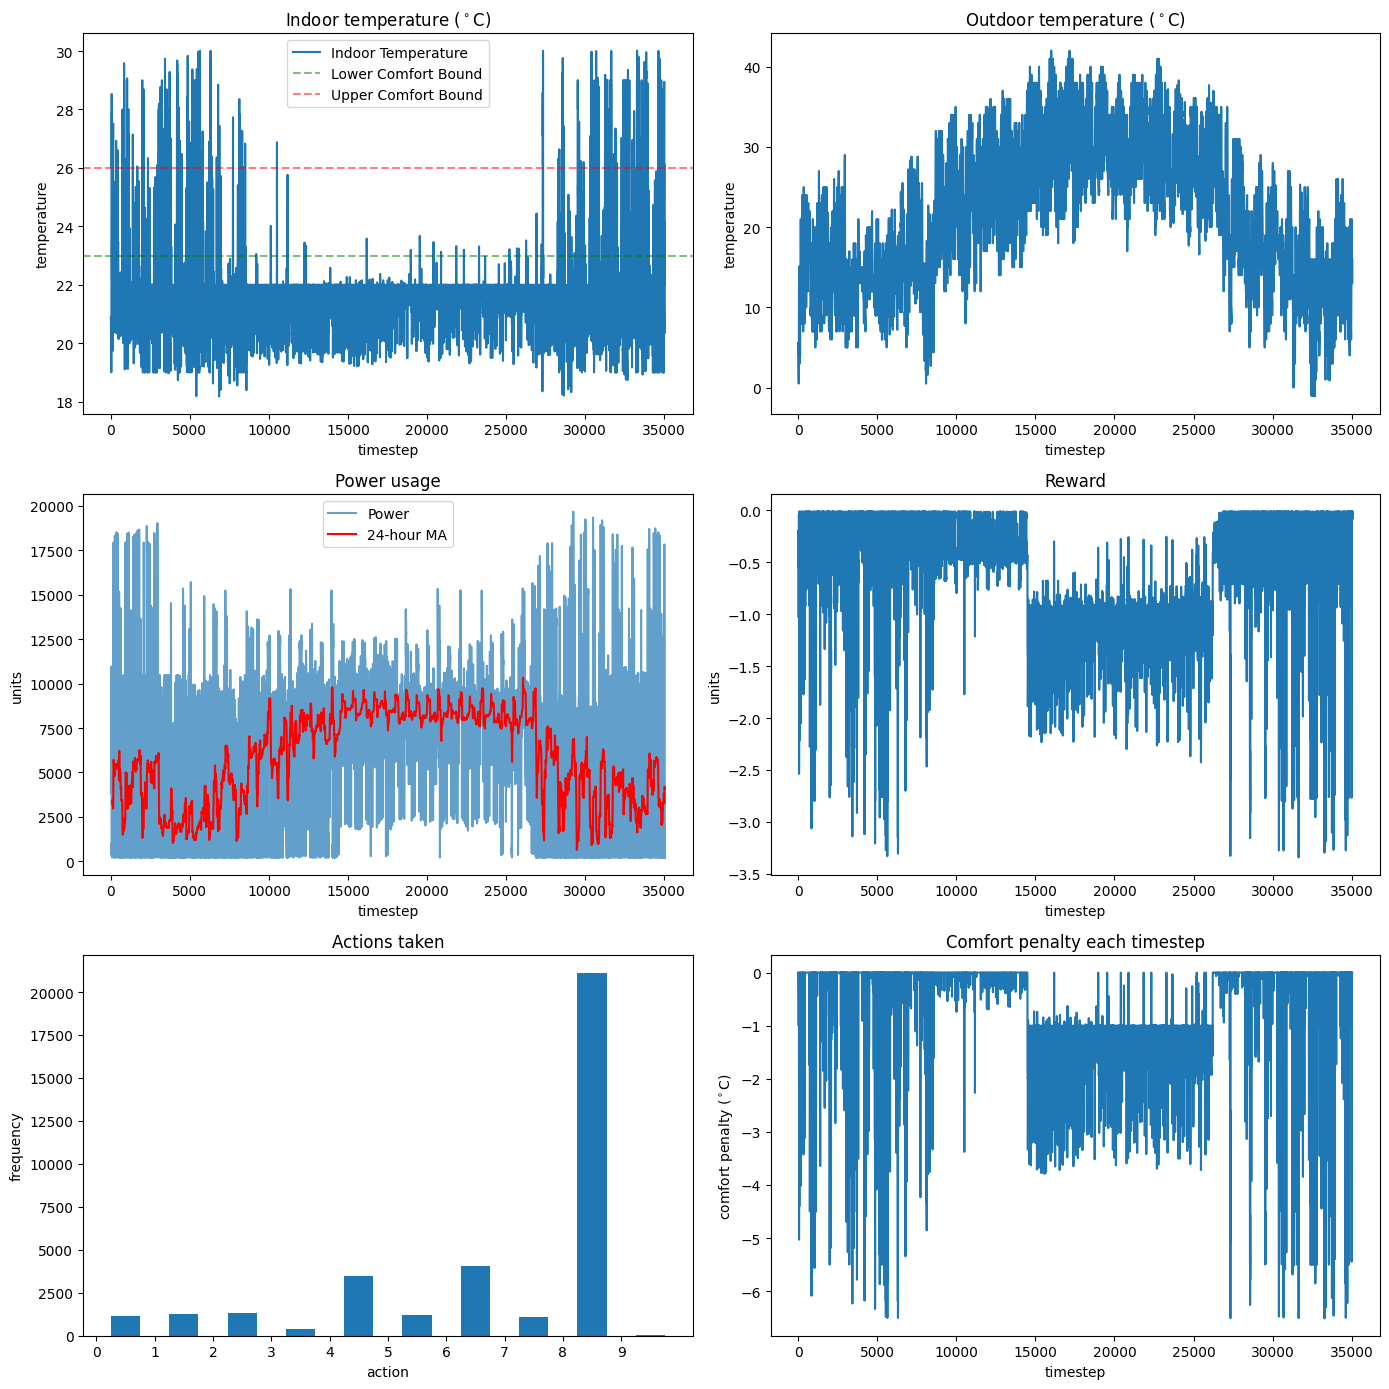

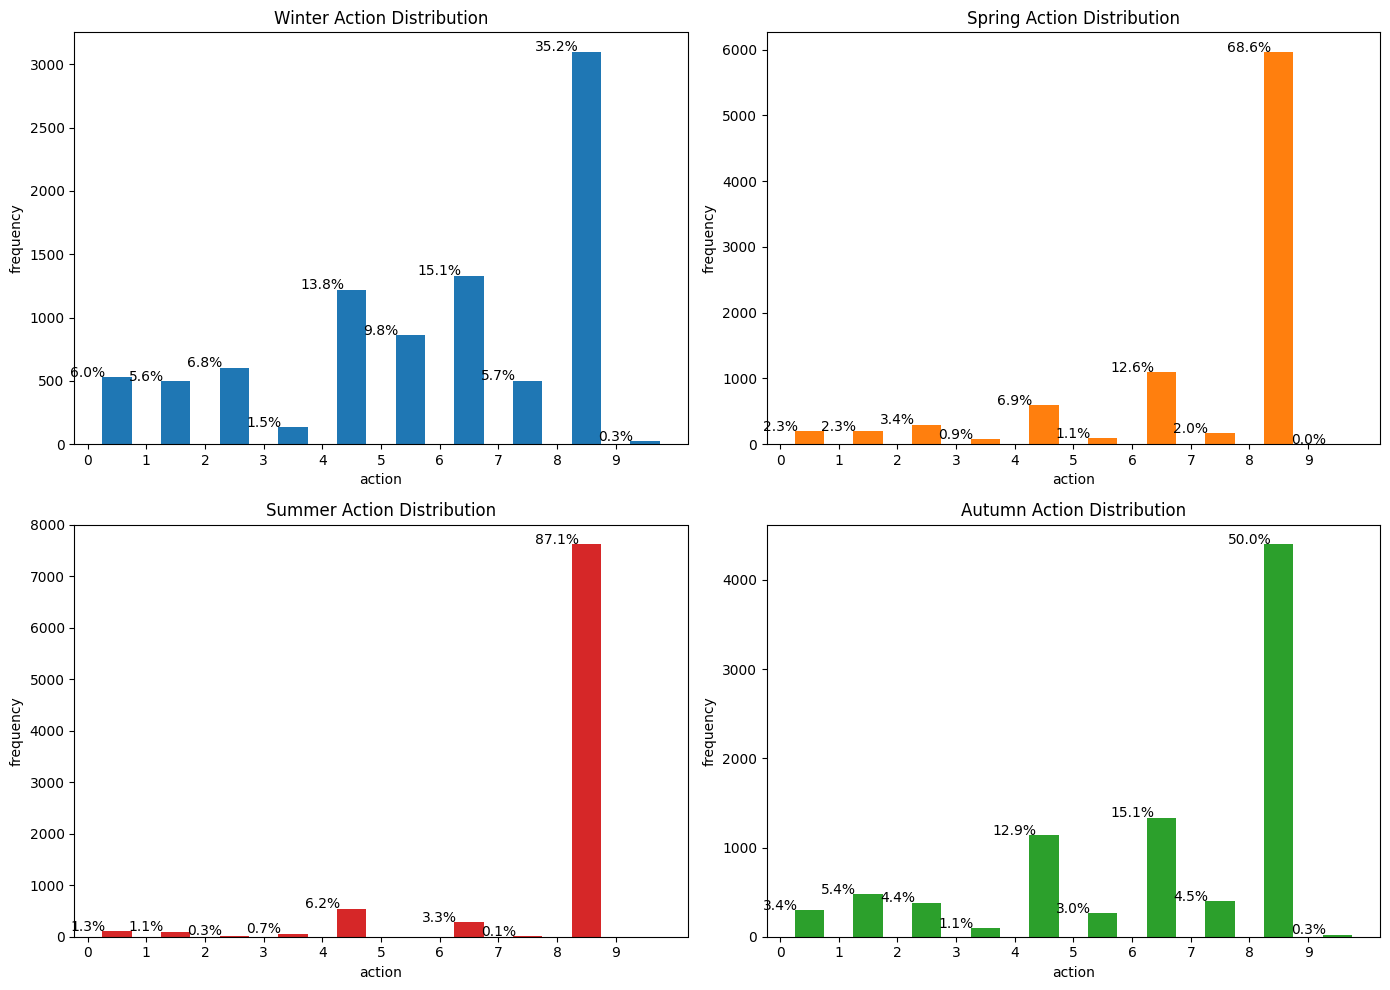

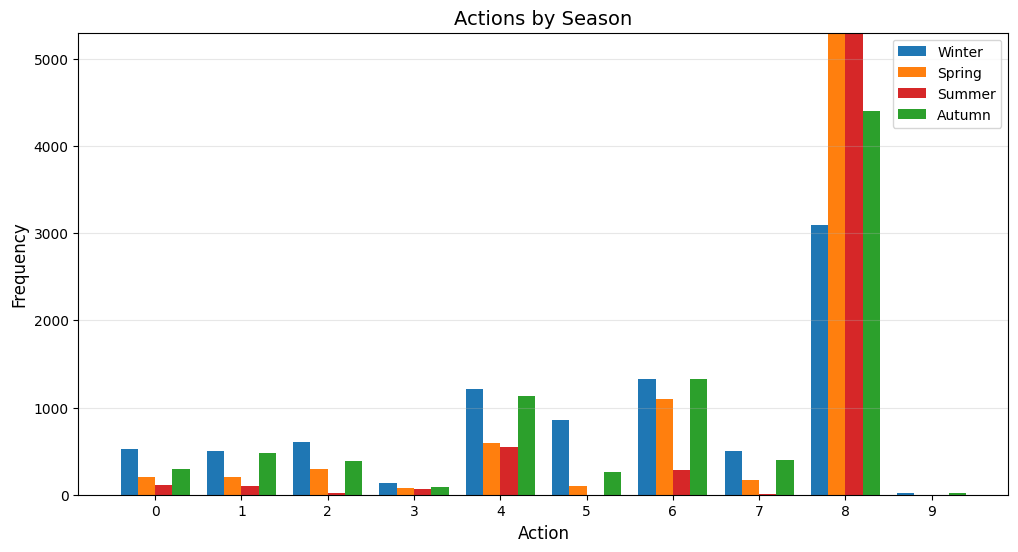

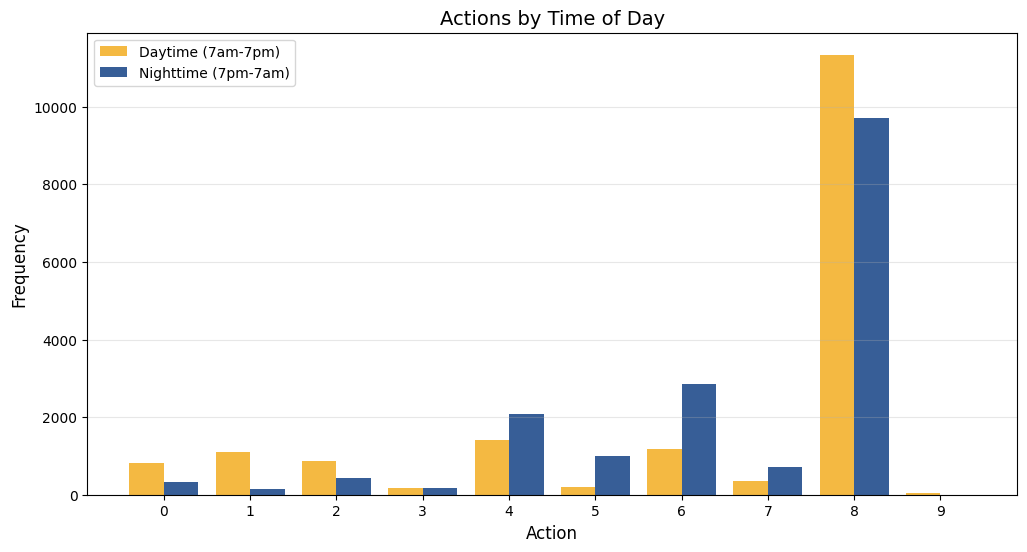

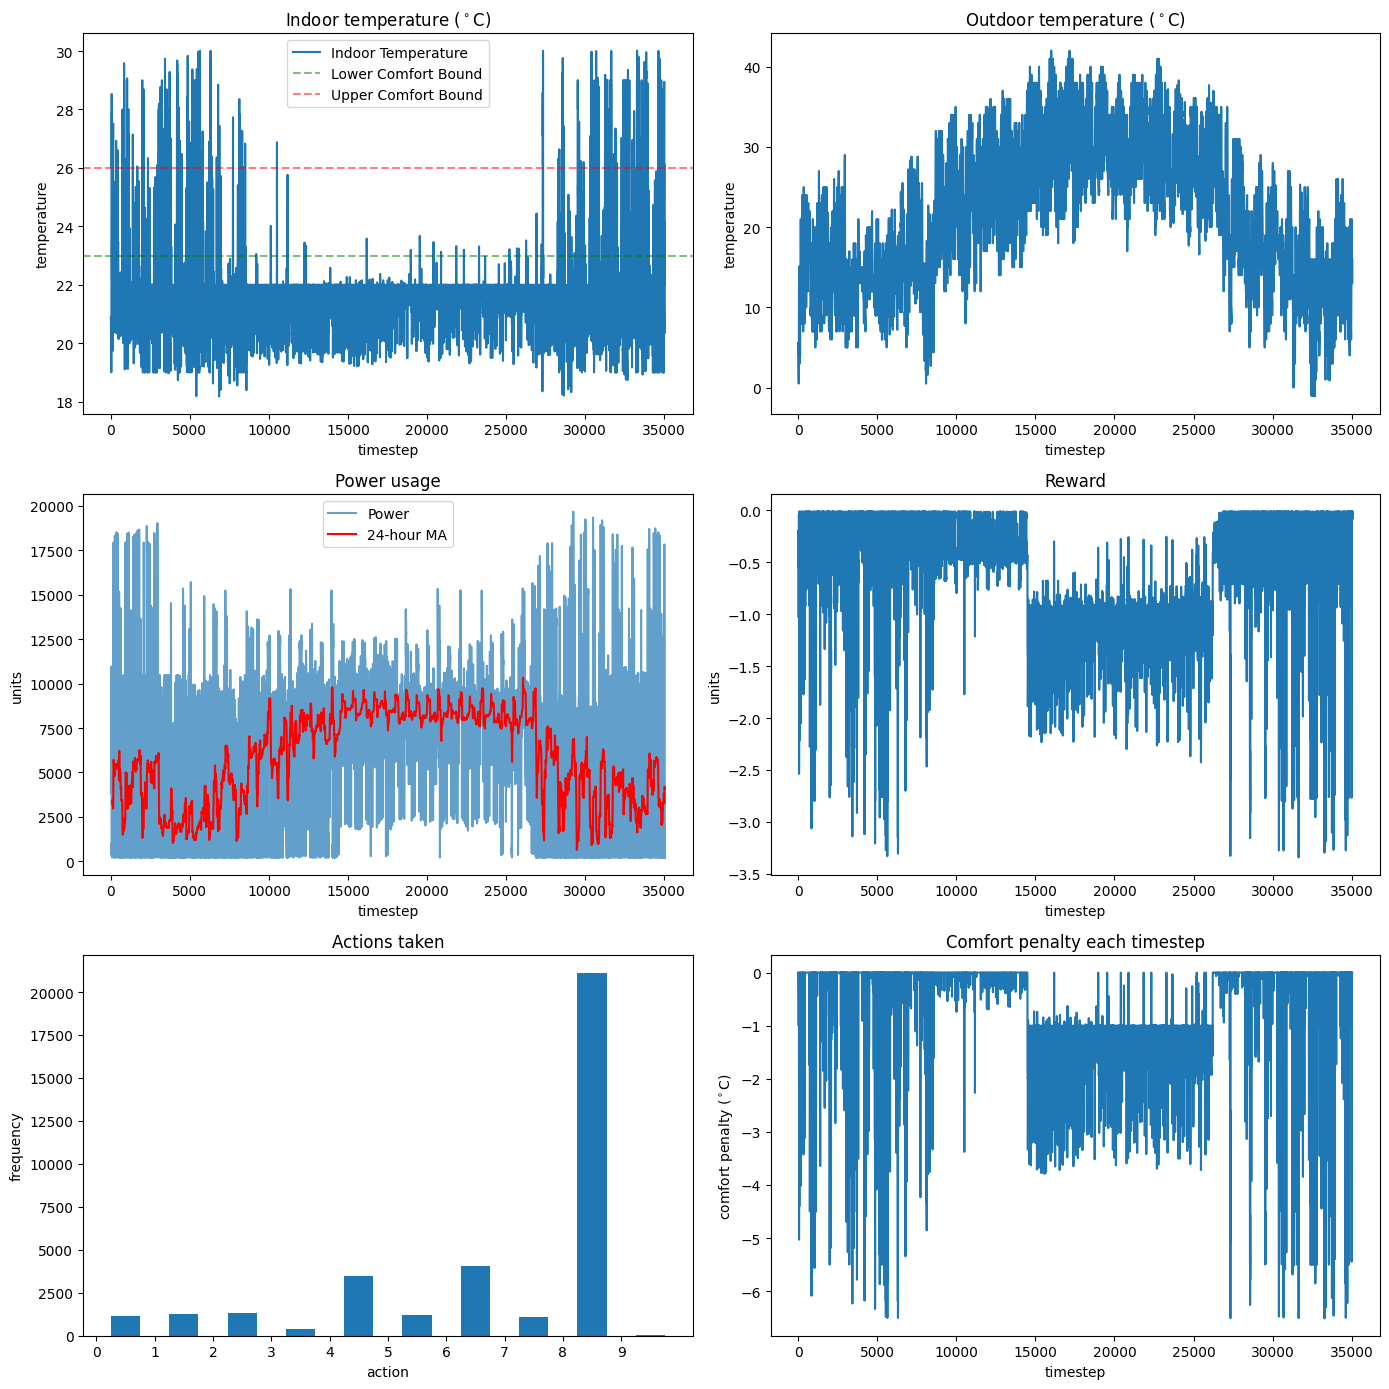

In [4]:
import gym
import energym

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import time
import random
import torch

from stable_baselines3 import DQN

# Import our custom policy
from custom_policy import CustomDQNPolicy

# Set seed for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# Parameters:
years = 7

frequency = 4   # DA on every hour

# You can replace these with the best parameters from hyperparameter optimization
gamma = 0.95  # Slightly higher than original
learning_starts = 35040/2   # training starts 6 months in
target_update_interval = 5000
buffer_size = 1000000
exploration_fraction = 0.8
exploration_initial_eps = 1
exploration_final_eps = 0.05
total_timesteps = years * 35040   # 7 years for training
eval_freq = 35040/2

#Param for quick train
# years = 0.01  # Just a fraction of a year
# total_timesteps = int(years * 35040)  # Very few steps
# learning_starts = 100
# eval_freq = 200

# Load data for DA
df = pd.read_csv("mean_runs/hot_means.csv")
new_temps = df['indoor_temp_mean'].tolist()
new_power = df['total_power_mean'].tolist()

# When using a fraction of a year, we need to adjust the temperature data accordingly
if years < 1:
    # For partial year training, use only a portion of the temperature data
    num_temps_needed = int(years * 35040)
    actual_temps = new_temps[:num_temps_needed]
else:
    # For multi-year training, repeat the temperature data
    actual_temps = new_temps * int(years)

# # Create the DA callback like if year < 1
# da_callback = EnhancedDataAssimilationCallback(
#     check_freq=frequency,
#     actual_temp=actual_temps,
#     temp_DA=True
# )

!pip install optuna  # For hyperparameter optimization

from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
from tqdm.notebook import tqdm

class ProgressBarCallback(BaseCallback):
    """
    Display a progress bar when training SB3 agent
    """
    def __init__(self, total_timesteps):
        super().__init__()
        self.pbar = None
        self.total_timesteps = total_timesteps
        
    def _on_training_start(self):
        self.pbar = tqdm(total=self.total_timesteps)

    def _on_step(self):
        self.pbar.update(1)
        return True
    
    def _on_training_end(self):
        self.pbar.close()
        self.pbar = None

# # Enhanced Data Assimilation Callback with improved state handling
# class EnhancedDataAssimilationCallback(BaseCallback):
    
#     def __init__(self, check_freq, actual_temp=None, actual_power=None, 
#                   temp_DA=False, power_DA=False, both_DA=False, verbose=1):
#         super(EnhancedDataAssimilationCallback, self).__init__(verbose)
#         self.check_freq = check_freq
#         # Number of time the callback was called:
#         self.n_calls = 0
#         # Actual states after step:
#         self.actual_temp = actual_temp
#         self.actual_power = actual_power

#         self.count = 0

#         self.temp_DA = temp_DA
#         self.power_DA = power_DA
#         self.both_DA = both_DA
        
#         # Track performance metrics
#         self.temp_errors = []
#         self.power_errors = []

#     def _on_step(self) -> bool:
#         if self.n_calls % self.check_freq == 0:
#             # Get current environment state
#             env = self.training_env.envs[0]
            
#             if self.temp_DA and self.actual_temp is not None:
#                 # Calculate error before update (for monitoring)
#                 if hasattr(env, 'current_temp'):
#                     self.temp_errors.append(abs(env.current_temp - self.actual_temp[self.count]))
                
#                 # Update temperature
#                 env.update_temp(self.actual_temp[self.count])

#             elif self.power_DA and self.actual_power is not None:
#                 # Calculate error before update (for monitoring)
#                 if hasattr(env, 'current_power'):
#                     self.power_errors.append(abs(env.current_power - self.actual_power[self.count]))
                
#                 # Update power
#                 env.update_power(self.actual_power[self.count])

#             elif self.both_DA and self.actual_temp is not None and self.actual_power is not None:
#                 # Update both
#                 env.update_both(self.actual_temp[self.count], self.actual_power[self.count])

#             self.count += 4
          
#         return True

# Enhanced Data Assimilation Callback with debugging
class EnhancedDataAssimilationCallback(BaseCallback):
    
    def __init__(self, check_freq, actual_temp=None, actual_power=None, 
                  temp_DA=False, power_DA=False, both_DA=False, verbose=1):
        super(EnhancedDataAssimilationCallback, self).__init__(verbose)
        self.check_freq = check_freq
        # Number of time the callback was called:
        self.n_calls = 0
        # Actual states after step:
        self.actual_temp = actual_temp
        self.actual_power = actual_power

        self.count = 0
        self.max_count = len(actual_temp) if actual_temp is not None else 0
        if actual_power is not None:
            self.max_count = max(self.max_count, len(actual_power))

        self.temp_DA = temp_DA
        self.power_DA = power_DA
        self.both_DA = both_DA
        
        # Add counters for debugging
        self.da_updates = 0
        self.total_calls = 0
        
        # Store before/after values for verification
        self.before_after_samples = []

    def _on_step(self) -> bool:
        self.total_calls += 1
        self.n_calls += 1
        
        if self.n_calls % self.check_freq == 0 and self.count < self.max_count:
            # Get the VecEnv
            vec_env = self.training_env
            
            # Get the underlying EnergyPlus environment
            # For VecEnv, we need to access the underlying env
            if hasattr(vec_env, 'envs'):
                env = vec_env.envs[0]
            elif hasattr(vec_env, 'venv'):
                env = vec_env.venv.envs[0]
            else:
                print("Warning: Could not access underlying environment")
                return True
            
            # Store original values for debugging
            orig_temp = None
            if hasattr(env, 'current_obs') and len(env.current_obs) > 8:
                orig_temp = env.current_obs[8]
            
            if self.temp_DA and self.actual_temp is not None and self.count < len(self.actual_temp):
                # Print debug info occasionally
                if self.da_updates % 50 == 0:
                    print(f"DA update #{self.da_updates}: Applying temp {self.actual_temp[self.count]:.2f}")
                    if orig_temp is not None:
                        print(f"  Before: {orig_temp:.2f}")
                
                # Apply the update
                env.update_temp(self.actual_temp[self.count])
                self.da_updates += 1
                
                # Verify the update worked
                if orig_temp is not None and hasattr(env, 'current_obs') and len(env.current_obs) > 8:
                    new_temp = env.current_obs[8]
                    if self.da_updates % 50 == 0:
                        print(f"  After: {new_temp:.2f}")
                        print(f"  Change: {new_temp - orig_temp:.2f}")
                    
                    # Store some samples for verification
                    if len(self.before_after_samples) < 10:
                        self.before_after_samples.append((orig_temp, new_temp))

            elif self.power_DA and self.actual_power is not None and self.count < len(self.actual_power):
                env.update_power(self.actual_power[self.count])
                self.da_updates += 1

            elif self.both_DA and self.actual_temp is not None and self.actual_power is not None:
                if self.count < len(self.actual_temp) and self.count < len(self.actual_power):
                    env.update_both(self.actual_temp[self.count], self.actual_power[self.count])
                    self.da_updates += 1

            self.count += 4
            # Reset count if we reach the end of data (for multi-year training)
            if self.count >= self.max_count:
                self.count = 0
                print("Reached end of DA data, resetting to beginning")

        return True
        
    def _on_training_end(self) -> None:
        """
        This event is triggered at the end of training
        """
        print(f"DA Summary: {self.da_updates} updates performed out of {self.total_calls} total steps")
        print(f"Sample of before/after temperature values:")
        for i, (before, after) in enumerate(self.before_after_samples):
            print(f"  Sample {i+1}: Before={before:.2f}, After={after:.2f}, Diff={after-before:.2f}")
            
# Create environment for training with seed
env = gym.make('Eplus-discrete-hot-v1')
env.seed(seed)
env.action_space.seed(seed)
env.observation_space.seed(seed)

# Create environment for evaluation with seed
eval_env = gym.make('Eplus-discrete-hot-v1')
eval_env.seed(seed)
eval_env.action_space.seed(seed)
eval_env.observation_space.seed(seed)

# Create model with custom policy:
model = DQN(CustomDQNPolicy, env, seed=seed, verbose=1, 
        gamma = gamma,
        learning_starts = learning_starts,
        target_update_interval = target_update_interval,
        buffer_size = buffer_size,
        exploration_fraction = exploration_fraction,
        exploration_initial_eps = exploration_initial_eps,
        exploration_final_eps = exploration_final_eps,
        # Additional improvements:
        learning_rate=3e-4,  # Slightly higher learning rate
        gradient_steps=1,    # One gradient step per environment step
        train_freq=4,        # Update the model every 4 steps
        batch_size=128)      # Larger batch size for more stable updates

# Create the evaluation callback
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./logs/",
    log_path="./logs/",
    eval_freq=int(eval_freq),
    n_eval_episodes=1,
    deterministic=True,
    render=False
)

# Create the progress bar callback
progress_callback = ProgressBarCallback(total_timesteps=total_timesteps)

# Combine callbacks
from stable_baselines3.common.callbacks import CallbackList
callbacks = CallbackList([progress_callback, eval_callback])


# Test the environment's update functions before training

def test_environment_updates():
    """Test that the environment update functions actually work"""
    print("\n=== Testing Environment Update Functions ===")
    
    # Create a test environment
    test_env = gym.make('Eplus-discrete-hot-v1')
    obs = test_env.reset()  # Get initial observation from reset
    
    print(f"Observation shape: {obs.shape if hasattr(obs, 'shape') else len(obs)}")
    
    # First, we need to make sure the environment has a current_obs attribute
    # Let's take a step to ensure the environment has processed at least one action
    action = test_env.action_space.sample()
    obs, _, _, _ = test_env.step(action)
    
    # Check if the environment has the current_obs attribute
    if not hasattr(test_env, 'current_obs') or test_env.current_obs is None:
        print("WARNING: Environment doesn't have a valid current_obs attribute.")
        print("This might be because the environment implementation doesn't store observations.")
        print("Let's try to fix this by manually setting current_obs:")
        
        # Try to set the current_obs attribute
        test_env.current_obs = obs
        print(f"Set current_obs to the latest observation with shape: {obs.shape if hasattr(obs, 'shape') else len(obs)}")
    
    # Now test the update methods
    if hasattr(test_env, 'current_obs') and test_env.current_obs is not None:
        print(f"Current observation available with shape: {test_env.current_obs.shape if hasattr(test_env.current_obs, 'shape') else len(test_env.current_obs)}")
        
        # Store initial values
        initial_temp = test_env.current_obs[8]
        initial_power = test_env.current_obs[15]
        
        # Test temperature update
        new_temp = initial_temp + 5.0  # 5 degrees higher
        print(f"Calling update_temp with new temperature: {new_temp:.2f}")
        test_env.update_temp(new_temp)
        
        # Check if update worked
        updated_temp = test_env.current_obs[8]
        print(f"Temperature update test:")
        print(f"  Initial: {initial_temp:.2f}°C")
        print(f"  Target: {new_temp:.2f}°C")
        print(f"  After update: {updated_temp:.2f}°C")
        print(f"  Change applied: {updated_temp - initial_temp:.2f}°C")
        
        # Take a step to see if the update persists
        action = test_env.action_space.sample()
        obs, _, _, _ = test_env.step(action)
        print(f"  After step: {test_env.current_obs[8]:.2f}°C")
        
        # Reset and test power update
        test_env.reset()
        action = test_env.action_space.sample()
        test_env.step(action)  # Take a step to ensure current_obs is set
        
        initial_power = test_env.current_obs[15]
        new_power = initial_power + 500  # Significant increase
        print(f"\nCalling update_power with new power: {new_power:.2f}")
        test_env.update_power(new_power)
        
        updated_power = test_env.current_obs[15]
        print(f"Power update test:")
        print(f"  Initial: {initial_power:.2f}")
        print(f"  Target: {new_power:.2f}")
        print(f"  After update: {updated_power:.2f}")
        print(f"  Change applied: {updated_power - initial_power:.2f}")
        
        # Take a step to see if the update persists
        action = test_env.action_space.sample()
        obs, _, _, _ = test_env.step(action)
        print(f"  After step: {test_env.current_obs[15]:.2f}")
        
        # Reset and test both update
        test_env.reset()
        action = test_env.action_space.sample()
        test_env.step(action)  # Take a step to ensure current_obs is set
        
        initial_temp = test_env.current_obs[8]
        initial_power = test_env.current_obs[15]
        new_temp = initial_temp + 3.0
        new_power = initial_power + 300
        print(f"\nCalling update_both with new temp: {new_temp:.2f} and power: {new_power:.2f}")
        test_env.update_both(new_temp, new_power)
        
        updated_temp = test_env.current_obs[8]
        updated_power = test_env.current_obs[15]
        print(f"Both update test:")
        print(f"  Initial temp: {initial_temp:.2f}°C, power: {initial_power:.2f}")
        print(f"  Target temp: {new_temp:.2f}°C, power: {new_power:.2f}")
        print(f"  After update temp: {updated_temp:.2f}°C, power: {updated_power:.2f}")
        print(f"  Change applied temp: {updated_temp - initial_temp:.2f}°C, power: {updated_power - initial_power:.2f}")
        
        # Take a step to see if the update persists
        action = test_env.action_space.sample()
        obs, _, _, _ = test_env.step(action)
        print(f"  After step temp: {test_env.current_obs[8]:.2f}°C, power: {test_env.current_obs[15]:.2f}")
    else:
        print("Could not access environment state variables.")
    
    # Clean up
    test_env.close()
    print("=== End of Environment Tests ===\n")
        
       
   
    
# Then, call the function before training
print("Testing environment update functions before training...")
test_environment_updates()    
    
# Train model:
start_time = time.time()

model.learn(total_timesteps=total_timesteps, callback=callbacks)

print()
print("--- %s seconds taken to train ---" % (time.time() - start_time))

model.save("DQN models/enhanced_DQN_hot")

env.close()
eval_env.close()

# Test model for 1 year:

model = DQN.load("DQN models/enhanced_DQN_hot", policy=CustomDQNPolicy)

env = gym.make('Eplus-discrete-hot-v1')
env.seed(seed)
env.action_space.seed(seed)
env.observation_space.seed(seed)

start_time = time.time()

for i in range(1):
    obs = env.reset()

    rewards = []
    total_power = []
    in_temp = []
    out_temp = []
    actions = []
    comfort_penalties = []
    done = False
    current_month = 0

    while not done:
        # Predict next step:
        a, _ = model.predict(obs, deterministic=True)  # Use deterministic=True for evaluation
        # Observe next state and reward:
        obs, reward, done, info = env.step(int(a))

        # Store information for plotting:
        rewards.append(reward)
        total_power.append(info['total_power'])
        in_temp.append(info['temperature'])
        out_temp.append(info['out_temperature'])
        actions.append(int(a))
        comfort_penalties.append(info['comfort_penalty'])

        if info['month'] != current_month: # display results every month
            current_month = info['month']
            print('Reward: ', sum(rewards), info)
    print('Episode ', i, 'Mean reward: ', np.mean(rewards), 'Cumulative reward: ', sum(rewards))
env.close()

print()
print("--- %s seconds taken to run ---" % (time.time() - start_time))

# Enhanced visualization with better plots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14,14))

# Temperature plot with comfort bounds
axes[0,0].plot(in_temp, label='Indoor Temperature')
axes[0,0].axhline(y=23, color='g', linestyle='--', alpha=0.5, label='Lower Comfort Bound')
axes[0,0].axhline(y=26, color='r', linestyle='--', alpha=0.5, label='Upper Comfort Bound')
axes[0,0].set_title('Indoor temperature ($^\circ$C)')
axes[0,0].set_xlabel('timestep')
axes[0,0].set_ylabel('temperature')
axes[0,0].legend()

# Outdoor temperature
axes[0,1].plot(out_temp)
axes[0,1].set_title('Outdoor temperature ($^\circ$C)')
axes[0,1].set_xlabel('timestep')
axes[0,1].set_ylabel('temperature')

# Power usage with moving average
axes[1,0].plot(total_power, alpha=0.7, label='Power')
# Add 24-hour moving average
window_size = 96  # 24 hours (15-min intervals)
power_ma = pd.Series(total_power).rolling(window=window_size).mean()
axes[1,0].plot(power_ma, color='red', label='24-hour MA')
axes[1,0].set_title('Power usage')
axes[1,0].set_xlabel('timestep')
axes[1,0].set_ylabel('units')
axes[1,0].legend()

# Reward
axes[1,1].plot(rewards)
axes[1,1].set_title('Reward')
axes[1,1].set_xlabel('timestep')
axes[1,1].set_ylabel('units')

# Actions histogram
axes[2,0].hist(actions, rwidth=0.5, bins=range(11))
axes[2,0].set_title('Actions taken')
axes[2,0].set_xlabel('action')
axes[2,0].set_ylabel('frequency')
axes[2,0].set_xticks(range(10))

# Comfort penalty
axes[2,1].plot(comfort_penalties)
axes[2,1].set_title('Comfort penalty each timestep')
axes[2,1].set_xlabel('timestep')
axes[2,1].set_ylabel('comfort penalty ($^\circ$C)')

plt.tight_layout()
plt.savefig('project_images/Enhanced_DQN_metrics_hot.png')

# Seasonal analysis (same as before)
winter = actions[33700:] + actions[:7450]
spring = actions[7450:16150]
summer = actions[16150:24900]
autumn = actions[24900:33700]

len(winter), len(spring), len(summer), len(autumn)

# split actions into seasons with enhanced visualization
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14,10))

# Add titles and better formatting
for ax, data, title, color in zip(
    axes.flatten(),
    [winter, spring, summer, autumn],
    ['Winter', 'Spring', 'Summer', 'Autumn'],
    ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c']
):
    ax.hist(data, rwidth=0.5, bins=range(11), color=color)
    ax.set_title(f'{title} Action Distribution')
    ax.set_xlabel('action')
    ax.set_ylabel('frequency')
    ax.set_xticks(range(10))
    
    # Add percentage labels on top of bars
    counts, _ = np.histogram(data, bins=range(11))
    total = len(data)
    for i, count in enumerate(counts):
        if count > 0:
            ax.text(i, count + 5, f'{count/total:.1%}', ha='center')

plt.tight_layout()
plt.savefig('project_images/Enhanced_DQN_actions_by_season_hot.png')

# Combined seasonal plot with enhanced visualization
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))

# Use better colors and add a grid
ax.hist(
    [winter, spring, summer, autumn], 
    rwidth=0.8, 
    label=['Winter', 'Spring', 'Summer', 'Autumn'], 
    bins=np.arange(11) - 0.5,
    color=['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c']
)

ax.set_title('Actions by Season', fontsize=14)
ax.set_xlabel('Action', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0,5300])
ax.set_xticks(list(range(10)))

plt.savefig('project_images/Enhanced_DQN_actions_by_season_combined_hot.png')

# Print comfort statistics with more detail
total_comfort_penalty = sum(comfort_penalties)
num_comfort_violations = sum([0 if (x == 0) else 1 for x in comfort_penalties])
percent_comfort_violations = (num_comfort_violations / len(comfort_penalties)) * 100

print(f"Total comfort penalty: {total_comfort_penalty:.2f}")
print(f"Number of comfort violations: {num_comfort_violations} out of {len(comfort_penalties)} timesteps")
print(f"Percentage of time in violation: {percent_comfort_violations:.2f}%")
print(f"Average comfort penalty when in violation: {total_comfort_penalty/max(1, num_comfort_violations):.2f}°C")

# Day/night analysis with enhanced visualization
day_time_steps = [(i*96 + j) for i in range(0, 365) for j in range(28,76)]
night_time_steps = [(i*96 + j) for i in range(0, 364) for j in range(76,124)]

day_actions = [actions[day_time_steps[i]] for i in range(len(day_time_steps))]
night_actions = [actions[night_time_steps[i]] for i in range(len(night_time_steps))]

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))

# Use better colors and add a grid
ax.hist(
    [day_actions, night_actions], 
    rwidth=0.8, 
    label=['Daytime (7am-7pm)', 'Nighttime (7pm-7am)'], 
    bins=np.arange(11) - 0.5,
    color=['#f4b942', '#375e97']
)

ax.set_title('Actions by Time of Day', fontsize=14)
ax.set_xlabel('Action', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(list(range(10)))

plt.savefig('project_images/Enhanced_DQN_actions_by_time_hot.png')

########  DQN run with DA (hot environment) using custom policy ########

# Load data for DA
df = pd.read_csv("mean_runs/hot_means.csv")
new_temps = df['indoor_temp_mean'].tolist()
new_power = df['total_power_mean'].tolist()

###### Temp DA only with enhanced model ######

# Create environment:
env = gym.make('Eplus-discrete-hot-v1')
env.seed(seed)
env.action_space.seed(seed)
env.observation_space.seed(seed)

eval_env = gym.make('Eplus-discrete-hot-v1')
eval_env.seed(seed)
eval_env.action_space.seed(seed)
eval_env.observation_space.seed(seed)

# Create model with custom policy:
model = DQN(CustomDQNPolicy, env, seed=seed, verbose=1, 
        gamma = gamma,
        learning_starts = learning_starts,
        target_update_interval = target_update_interval,
        buffer_size = buffer_size,
        exploration_fraction = exploration_fraction,
        exploration_initial_eps = exploration_initial_eps,
        exploration_final_eps = exploration_final_eps,
        # Additional improvements:
        learning_rate=3e-4,
        gradient_steps=1,
        train_freq=4,
        batch_size=128)

# Create the evaluation callback
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./logs/da_logs/",
    log_path="./logs/da_logs/",
    eval_freq=int(eval_freq),
    n_eval_episodes=1,
    deterministic=True,
    render=False
)

# Create the progress bar callback
progress_callback = ProgressBarCallback(total_timesteps=total_timesteps)

# Create the DA callback
if years > 1:
    
    da_callback = EnhancedDataAssimilationCallback(
        check_freq=frequency, 
        actual_temp=years*new_temps, 
        temp_DA=True
    )
else:
    # Create the DA callback
    da_callback = EnhancedDataAssimilationCallback(
        check_freq=frequency,
        actual_temp=actual_temps,
        temp_DA=True
    )

# Combine callbacks
callbacks = CallbackList([progress_callback, eval_callback, da_callback])

start_time = time.time()

model.learn(total_timesteps=total_timesteps, callback=callbacks)

print()
print("--- %s seconds taken to train ---" % (time.time() - start_time))

model.save("DQN models/enhanced_temp_DA_DQN_hot")

env.close()
eval_env.close()

# Test the enhanced DA model
model = DQN.load("DQN models/enhanced_temp_DA_DQN_hot", policy=CustomDQNPolicy)

env = gym.make('Eplus-discrete-hot-v1')
env.seed(seed)
env.action_space.seed(seed)
env.observation_space.seed(seed)

start_time = time.time()

for i in range(1):
    obs = env.reset()

    rewards = []
    total_power = []
    in_temp = []
    out_temp = []
    actions = []
    comfort_penalties = []
    done = False
    current_month = 0

    while not done:
        # Predict next step:
        a, _ = model.predict(obs, deterministic=True)
        # Observe next state and reward:
        obs, reward, done, info = env.step(int(a))

        # Store information for plotting:
        rewards.append(reward)
        total_power.append(info['total_power'])
        in_temp.append(info['temperature'])
        out_temp.append(info['out_temperature'])
        actions.append(int(a))
        comfort_penalties.append(info['comfort_penalty'])

        if info['month'] != current_month: # display results every month
            current_month = info['month']
            print('Reward: ', sum(rewards), info)
    print('Episode ', i, 'Mean reward: ', np.mean(rewards), 'Cumulative reward: ', sum(rewards))
env.close()

print()
print("--- %s seconds taken to run ---" % (time.time() - start_time))

# Enhanced visualization for DA model results
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14,14))

# Temperature plot with comfort bounds
axes[0,0].plot(in_temp, label='Indoor Temperature')
axes[0,0].axhline(y=23, color='g', linestyle='--', alpha=0.5, label='Lower Comfort Bound')
axes[0,0].axhline(y=26, color='r', linestyle='--', alpha=0.5, label='Upper Comfort Bound')
axes[0,0].set_title('Indoor temperature ($^\circ$C)')
axes[0,0].set_xlabel('timestep')
axes[0,0].set_ylabel('temperature')
axes[0,0].legend()

# Outdoor temperature
axes[0,1].plot(out_temp)
axes[0,1].set_title('Outdoor temperature ($^\circ$C)')
axes[0,1].set_xlabel('timestep')
axes[0,1].set_ylabel('temperature')

# Power usage with moving average
axes[1,0].plot(total_power, alpha=0.7, label='Power')
# Add 24-hour moving average
window_size = 96  # 24 hours (15-min intervals)
power_ma = pd.Series(total_power).rolling(window=window_size).mean()
axes[1,0].plot(power_ma, color='red', label='24-hour MA')
axes[1,0].set_title('Power usage')
axes[1,0].set_xlabel('timestep')
axes[1,0].set_ylabel('units')
axes[1,0].legend()

# Reward
axes[1,1].plot(rewards)
axes[1,1].set_title('Reward')
axes[1,1].set_xlabel('timestep')
axes[1,1].set_ylabel('units')

# Actions histogram
axes[2,0].hist(actions, rwidth=0.5, bins=range(11))
axes[2,0].set_title('Actions taken')
axes[2,0].set_xlabel('action')
axes[2,0].set_ylabel('frequency')
axes[2,0].set_xticks(range(10))

# Comfort penalty
axes[2,1].plot(comfort_penalties)
axes[2,1].set_title('Comfort penalty each timestep')
axes[2,1].set_xlabel('timestep')
axes[2,1].set_ylabel('comfort penalty ($^\circ$C)')

plt.tight_layout()
plt.savefig('project_images/Enhanced_DA_DQN_metrics_hot.png')

# Compare the two models (with and without DA)
# Load results from both models for comparison
regular_model = DQN.load("DQN models/enhanced_DQN_hot", policy=CustomDQNPolicy)
da_model = DQN.load("DQN models/enhanced_temp_DA_DQN_hot", policy=CustomDQNPolicy)

# Function to evaluate a model
def evaluate_model(model, env_id, seed=42, episodes=1):
    env = gym.make(env_id)
    env.seed(seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    
    all_rewards = []
    all_power = []
    all_temps = []
    all_comfort = []
    all_actions = []
    
    for _ in range(episodes):
        obs = env.reset()
        done = False
        rewards = []
        power = []
        temps = []
        comfort = []
        actions = []
        
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, info = env.step(int(action))
            
            rewards.append(reward)
            power.append(info['total_power'])
            temps.append(info['temperature'])
            comfort.append(info['comfort_penalty'])
            actions.append(int(action))
        
        all_rewards.append(rewards)
        all_power.append(power)
        all_temps.append(temps)
        all_comfort.append(comfort)
        all_actions.append(actions)
    
    env.close()
    
    return {
        'rewards': all_rewards,
        'power': all_power,
        'temps': all_temps,
        'comfort': all_comfort,
        'actions': all_actions
    }

# Evaluate both models
regular_results = evaluate_model(regular_model, 'Eplus-discrete-hot-v1', seed=seed)
da_results = evaluate_model(da_model, 'Eplus-discrete-hot-v1', seed=seed)




===== Performance Comparison =====
Metric                    Without DA      With DA         Improvement    
----------------------------------------------------------------------
Total Reward              -21712.86       -21712.86       0.00           %
Total Power Usage         207688917.94    207688917.94    0.00           %
Total Comfort Penalty     -22656.82       -22656.82       -0.00          %
Comfort Violations (%)    0.00            0.00            0.00           %

Experiment completed! Enhanced models with and without DA have been trained, evaluated, and compared.


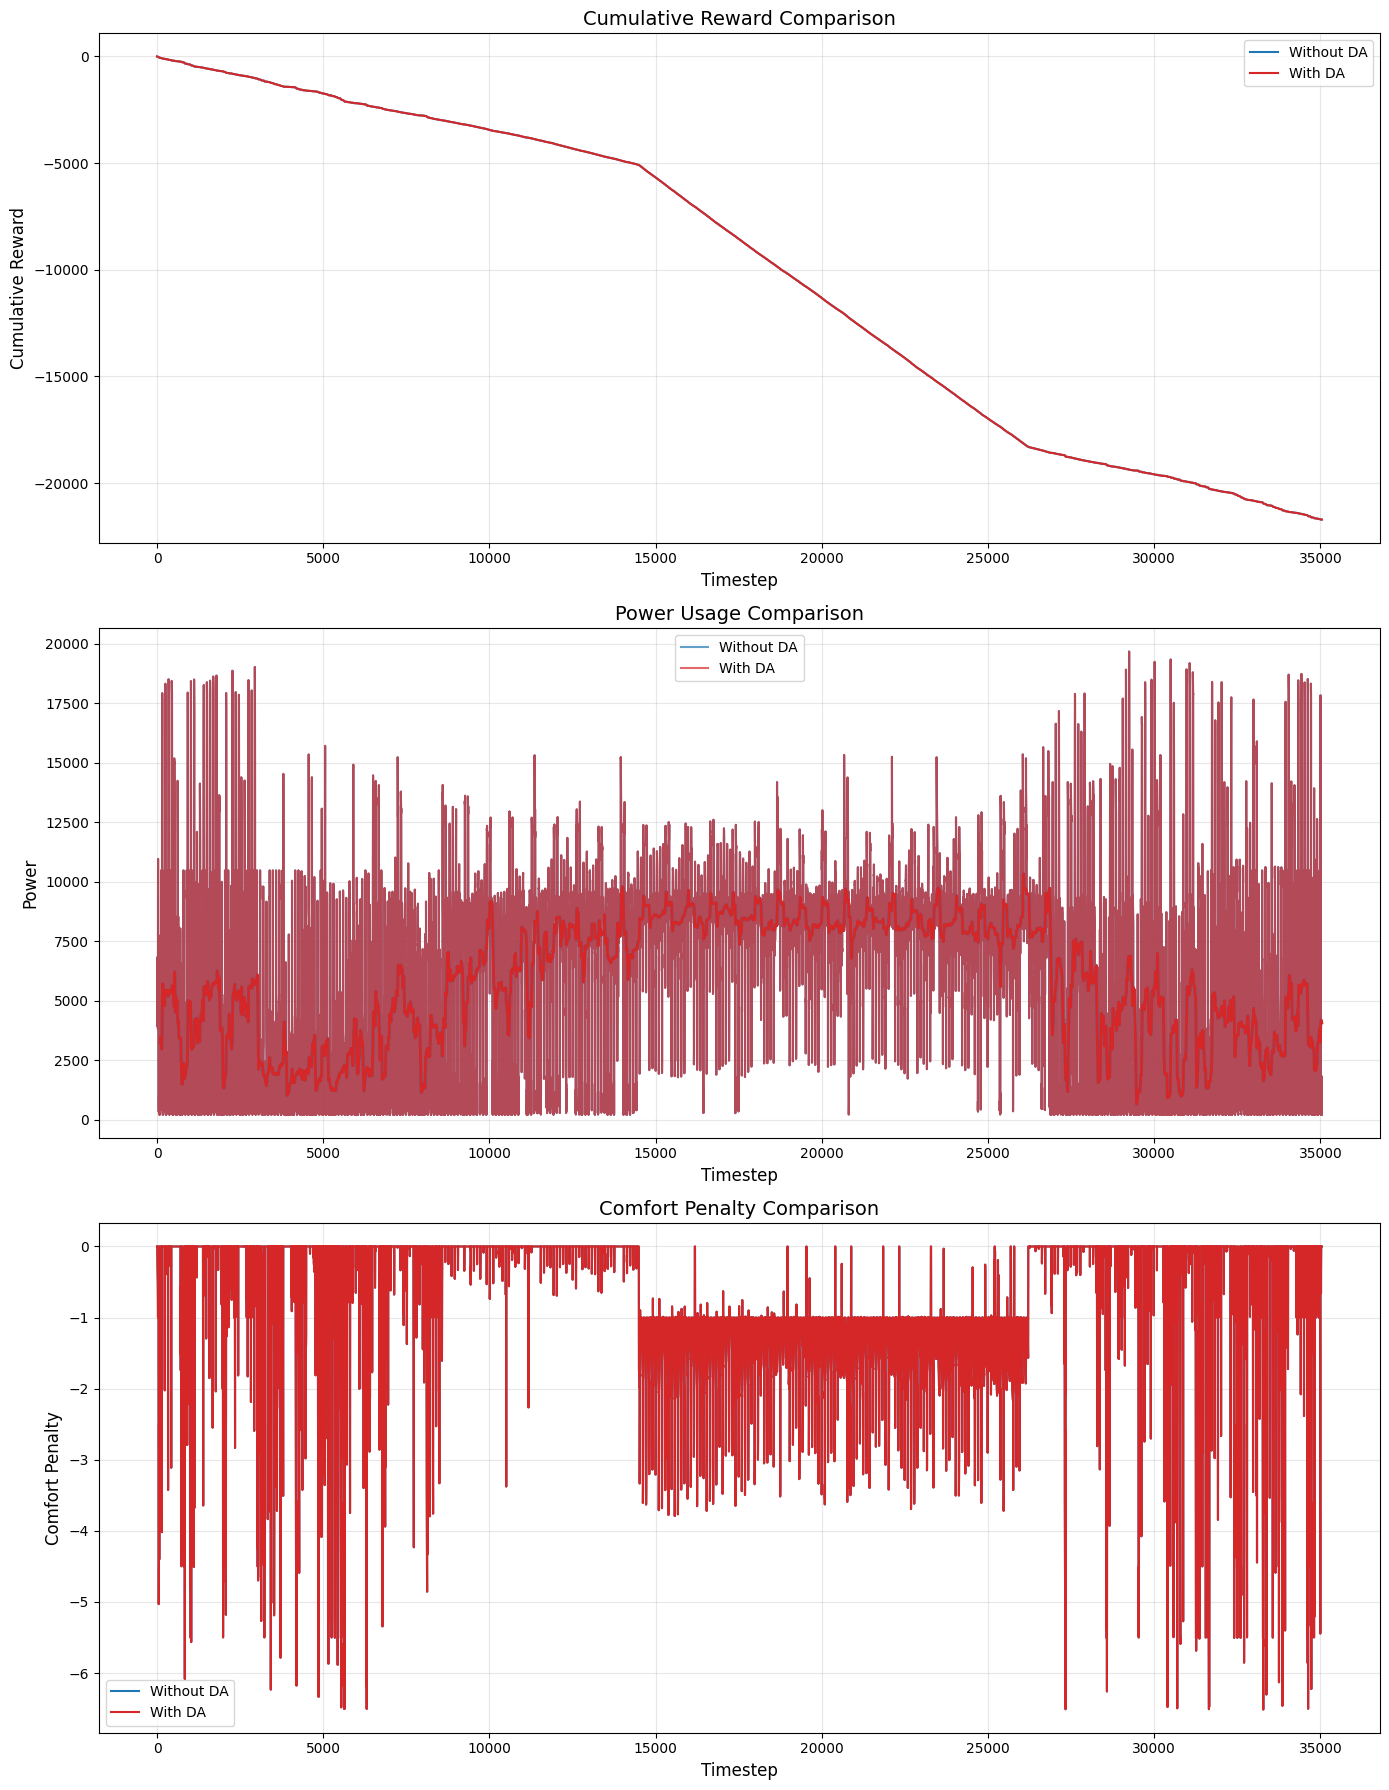

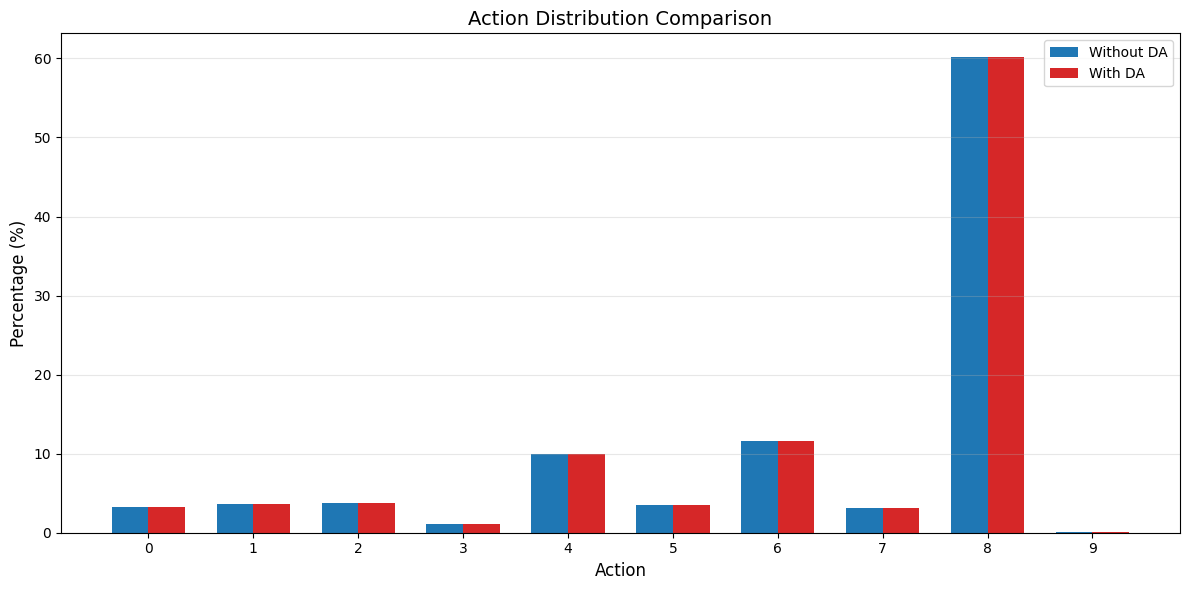

In [6]:
# Create comparison plots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 18))


# Cumulative reward comparison
cum_reward_regular = np.cumsum(regular_results['rewards'][0])
cum_reward_da = np.cumsum(da_results['rewards'][0])

axes[0].plot(cum_reward_regular, label='Without DA', color='#1f77b4')
axes[0].plot(cum_reward_da, label='With DA', color='#d62728')
axes[0].set_title('Cumulative Reward Comparison', fontsize=14)
axes[0].set_xlabel('Timestep', fontsize=12)
axes[0].set_ylabel('Cumulative Reward', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Power usage comparison
axes[1].plot(regular_results['power'][0], label='Without DA', color='#1f77b4', alpha=0.7)
axes[1].plot(da_results['power'][0], label='With DA', color='#d62728', alpha=0.7)
# Add moving averages
window_size = 96  # 24 hours
power_ma_regular = pd.Series(regular_results['power'][0]).rolling(window=window_size).mean()
power_ma_da = pd.Series(da_results['power'][0]).rolling(window=window_size).mean()
axes[1].plot(power_ma_regular, color='#1f77b4', linewidth=2)
axes[1].plot(power_ma_da, color='#d62728', linewidth=2)
axes[1].set_title('Power Usage Comparison', fontsize=14)
axes[1].set_xlabel('Timestep', fontsize=12)
axes[1].set_ylabel('Power', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

# Comfort violation comparison
axes[2].plot(regular_results['comfort'][0], label='Without DA', color='#1f77b4')
axes[2].plot(da_results['comfort'][0], label='With DA', color='#d62728')
axes[2].set_title('Comfort Penalty Comparison', fontsize=14)
axes[2].set_xlabel('Timestep', fontsize=12)
axes[2].set_ylabel('Comfort Penalty', fontsize=12)
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('project_images/Enhanced_DA_vs_Regular_Comparison.png')

# Calculate and print summary statistics
def calculate_stats(results):
    total_reward = sum(results['rewards'][0])
    total_power = sum(results['power'][0])
    total_comfort_penalty = sum(results['comfort'][0])
    comfort_violations = sum([1 for x in results['comfort'][0] if x > 0])
    violation_percentage = (comfort_violations / len(results['comfort'][0])) * 100
    
    # Action distribution
    action_counts = np.bincount(results['actions'][0], minlength=10)
    action_percentages = action_counts / len(results['actions'][0]) * 100
    
    return {
        'total_reward': total_reward,
        'total_power': total_power,
        'total_comfort_penalty': total_comfort_penalty,
        'comfort_violations': comfort_violations,
        'violation_percentage': violation_percentage,
        'action_percentages': action_percentages
    }

regular_stats = calculate_stats(regular_results)
da_stats = calculate_stats(da_results)

# Print comparison table
print("\n===== Performance Comparison =====")
print(f"{'Metric':<25} {'Without DA':<15} {'With DA':<15} {'Improvement':<15}")
print("-" * 70)
print(f"{'Total Reward':<25} {regular_stats['total_reward']:<15.2f} {da_stats['total_reward']:<15.2f} {((da_stats['total_reward'] - regular_stats['total_reward']) / abs(regular_stats['total_reward'])) * 100:<15.2f}%")
print(f"{'Total Power Usage':<25} {regular_stats['total_power']:<15.2f} {da_stats['total_power']:<15.2f} {((regular_stats['total_power'] - da_stats['total_power']) / regular_stats['total_power']) * 100:<15.2f}%")
print(f"{'Total Comfort Penalty':<25} {regular_stats['total_comfort_penalty']:<15.2f} {da_stats['total_comfort_penalty']:<15.2f} {((regular_stats['total_comfort_penalty'] - da_stats['total_comfort_penalty']) / regular_stats['total_comfort_penalty']) * 100:<15.2f}%")
print(f"{'Comfort Violations (%)':<25} {regular_stats['violation_percentage']:<15.2f} {da_stats['violation_percentage']:<15.2f} {(regular_stats['violation_percentage'] - da_stats['violation_percentage']):<15.2f}%")

# Create a bar chart comparing action distributions
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(10)
width = 0.35

ax.bar(x - width/2, regular_stats['action_percentages'], width, label='Without DA', color='#1f77b4')
ax.bar(x + width/2, da_stats['action_percentages'], width, label='With DA', color='#d62728')

ax.set_title('Action Distribution Comparison', fontsize=14)
ax.set_xlabel('Action', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticks(x)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('project_images/Enhanced_DA_vs_Regular_Action_Distribution.png')

print("\nExperiment completed! Enhanced models with and without DA have been trained, evaluated, and compared.")

In [8]:
# Function to compare the two models with detailed analysis
def compare_models_detailed(regular_results, da_results):
    """Compare performance metrics between regular and DA models with detailed analysis"""
    print("\n===== Performance Comparison =====")
    
    # Extract data from results
    reg_rewards = regular_results['rewards'][0]
    da_rewards = da_results['rewards'][0]
    
    reg_power = regular_results['power'][0]
    da_power = da_results['power'][0]
    
    reg_temps = regular_results['temps'][0]
    da_temps = da_results['temps'][0]
    
    reg_comfort = regular_results['comfort'][0]
    da_comfort = da_results['comfort'][0]
    
    reg_actions = regular_results['actions'][0]
    da_actions = da_results['actions'][0]
    
    # Calculate summary metrics
    reg_total_reward = sum(reg_rewards)
    da_total_reward = sum(da_rewards)
    
    reg_total_power = sum(reg_power)
    da_total_power = sum(da_power)
    
    reg_total_comfort = sum(reg_comfort)
    da_total_comfort = sum(da_comfort)
    
    reg_violations = sum([1 for c in reg_comfort if c < 0])
    da_violations = sum([1 for c in da_comfort if c < 0])
    
    reg_violations_pct = (reg_violations / len(reg_comfort)) * 100
    da_violations_pct = (da_violations / len(da_comfort)) * 100
    
    # Check if the results are identical
    rewards_identical = np.array_equal(reg_rewards, da_rewards)
    power_identical = np.array_equal(reg_power, da_power)
    temps_identical = np.array_equal(reg_temps, da_temps)
    comfort_identical = np.array_equal(reg_comfort, da_comfort)
    actions_identical = np.array_equal(reg_actions, da_actions)
    
    print("Checking for identical trajectories:")
    print(f"  Rewards identical: {rewards_identical}")
    print(f"  Power identical: {power_identical}")
    print(f"  Temperatures identical: {temps_identical}")
    print(f"  Comfort identical: {comfort_identical}")
    print(f"  Actions identical: {actions_identical}")
    
    if rewards_identical and power_identical and temps_identical and comfort_identical and actions_identical:
        print("\nWARNING: All trajectories are identical! This suggests DA might not be working.")
        print("Check that different models were used and DA updates are being applied.")
    
    # Print comparison table
    print("\nPerformance Metrics:")
    print(f"{'Metric':<25} {'Without DA':<15} {'With DA':<15} {'Difference':<15} {'% Change':<15}")
    print("-" * 85)
    
    # Total reward
    reward_diff = da_total_reward - reg_total_reward
    reward_pct = (reward_diff / abs(reg_total_reward)) * 100 if reg_total_reward != 0 else 0
    print(f"{'Total Reward':<25} {reg_total_reward:<15.2f} {da_total_reward:<15.2f} {reward_diff:<15.2f} {reward_pct:<14.2f}%")
    
    # Total power
    power_diff = da_total_power - reg_total_power
    power_pct = (power_diff / reg_total_power) * 100 if reg_total_power != 0 else 0
    print(f"{'Total Power Usage':<25} {reg_total_power:<15.2f} {da_total_power:<15.2f} {power_diff:<15.2f} {power_pct:<14.2f}%")
    
    # Comfort penalty
    comfort_diff = da_total_comfort - reg_total_comfort
    comfort_pct = (comfort_diff / abs(reg_total_comfort)) * 100 if reg_total_comfort != 0 else 0
    print(f"{'Total Comfort Penalty':<25} {reg_total_comfort:<15.2f} {da_total_comfort:<15.2f} {comfort_diff:<15.2f} {comfort_pct:<14.2f}%")
    
    # Comfort violations
    violations_diff = da_violations - reg_violations
    violations_pct_change = (violations_diff / reg_violations) * 100 if reg_violations != 0 else 0
    print(f"{'Comfort Violations':<25} {reg_violations:<15d} {da_violations:<15d} {violations_diff:<15d} {violations_pct_change:<14.2f}%")
    print(f"{'Comfort Violations (%)':<25} {reg_violations_pct:<15.2f} {da_violations_pct:<15.2f} {da_violations_pct-reg_violations_pct:<15.2f} {'-':<14}")
    
    # Action distribution comparison
    print("\nAction Distribution Comparison:")
    reg_action_counts = np.bincount(reg_actions, minlength=10)
    da_action_counts = np.bincount(da_actions, minlength=10)
    
    print(f"{'Action':<10} {'Without DA':<15} {'With DA':<15} {'Difference':<15}")
    print("-" * 55)
    for i in range(10):
        diff = da_action_counts[i] - reg_action_counts[i]
        print(f"{i:<10} {reg_action_counts[i]:<15d} {da_action_counts[i]:<15d} {diff:<15d}")
    
    return {
        'regular': {
            'total_reward': reg_total_reward,
            'total_power': reg_total_power,
            'comfort_penalty': reg_total_comfort,
            'comfort_violations': reg_violations,
            'comfort_violations_pct': reg_violations_pct
        },
        'da': {
            'total_reward': da_total_reward,
            'total_power': da_total_power,
            'comfort_penalty': da_total_comfort,
            'comfort_violations': da_violations,
            'comfort_violations_pct': da_violations_pct
        }
    }

# Use the detailed comparison function
comparison_results = compare_models_detailed(regular_results, da_results)


===== Performance Comparison =====
Checking for identical trajectories:
  Rewards identical: True
  Power identical: True
  Temperatures identical: True
  Comfort identical: True
  Actions identical: True

Check that different models were used and DA updates are being applied.

Performance Metrics:
Metric                    Without DA      With DA         Difference      % Change       
-------------------------------------------------------------------------------------
Total Reward              -21712.86       -21712.86       0.00            0.00          %
Total Power Usage         207688917.94    207688917.94    0.00            0.00          %
Total Comfort Penalty     -22656.82       -22656.82       0.00            0.00          %
Comfort Violations        15478           15478           0               0.00          %
Comfort Violations (%)    44.17           44.17           0.00            -             

Action Distribution Comparison:
Action     Without DA      With DA       